In [1]:
set.seed(42)

brilho_estelar <- rnorm(n = 1000, mean = 15.5, sd = 0.8)

In [2]:
summary(brilho_estelar)
mean(brilho_estelar)
sd(brilho_estelar)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  12.80   14.96   15.49   15.48   16.03   18.30 

[1] 15.47934

[1] 0.802017

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The dot-dot notation (`..density..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(density)` instead.”


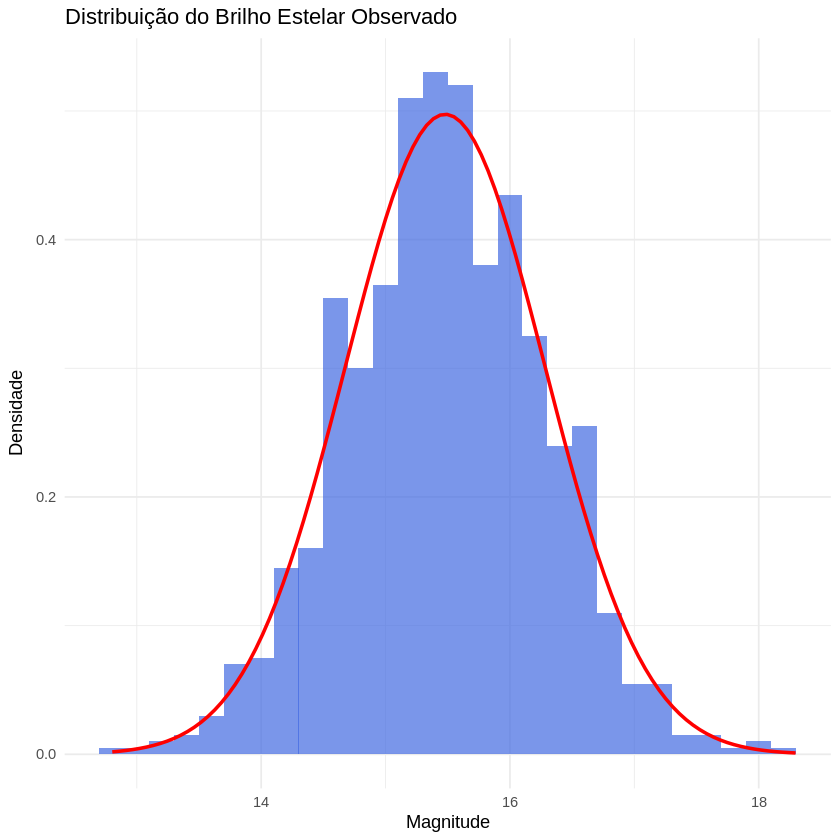

In [3]:
library(ggplot2)

df <- data.frame(brilho = brilho_estelar)

ggplot(df, aes(x = brilho)) +
  geom_histogram(aes(y = ..density..),
                 binwidth = 0.2,
                 fill = "royalblue",
                 alpha = 0.7) +
  stat_function(
    fun = dnorm,
    args = list(mean = mean(df$brilho), sd = sd(df$brilho)),
    color = "red",
    size = 1
  ) +
  theme_minimal() +
  labs(
    title = "Distribuição do Brilho Estelar Observado",
    x = "Magnitude",
    y = "Densidade"
  )

In [4]:
media_amostral <- mean(brilho_estelar)
erro_padrao <- sd(brilho_estelar) / sqrt(1000)

ic_95 <- c(
  media_amostral - 1.96 * erro_padrao,
  media_amostral + 1.96 * erro_padrao
)

ic_95

[1] 15.42963 15.52905

In [5]:
t.test(brilho_estelar, mu = 15.5)


	One Sample t-test

data:  brilho_estelar
t = -0.81459, df = 999, p-value = 0.4155
alternative hypothesis: true mean is not equal to 15.5
95 percent confidence interval:
 15.42957 15.52911
sample estimates:
mean of x 
 15.47934 


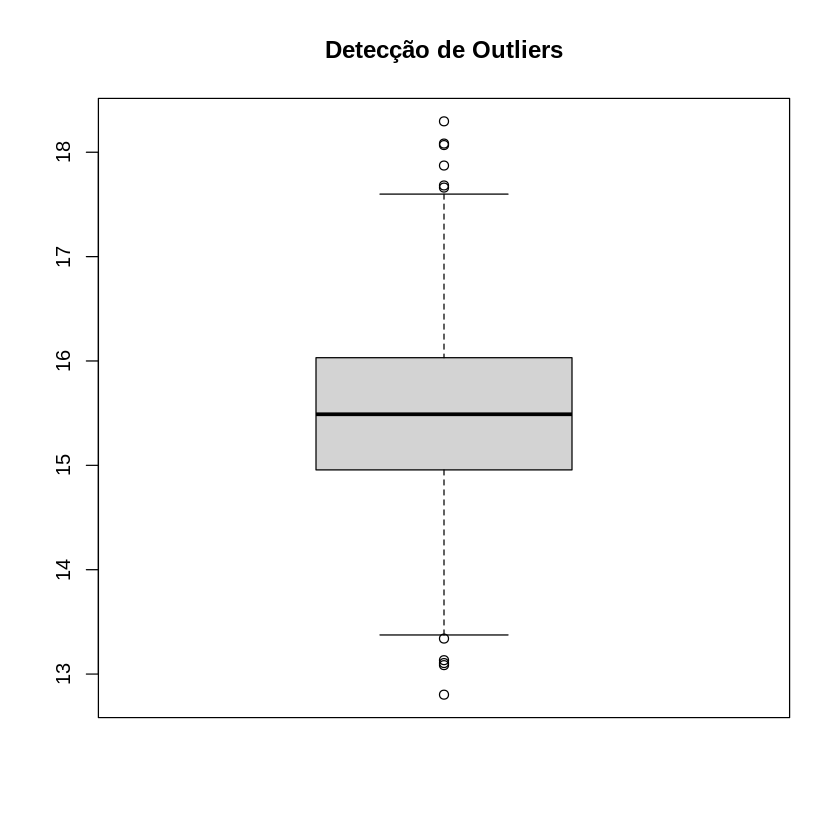

In [6]:
boxplot(brilho_estelar, main = "Detecção de Outliers")

In [7]:
Q1 <- quantile(brilho_estelar, 0.25)
Q3 <- quantile(brilho_estelar, 0.75)
IQR_val <- Q3 - Q1

limite_inf <- Q1 - 1.5 * IQR_val
limite_sup <- Q3 + 1.5 * IQR_val

outliers <- brilho_estelar[
  brilho_estelar < limite_inf | brilho_estelar > limite_sup
]

length(outliers)

[1] 11

Conclusão:
A simulação das medições de brilho estelar apresentou comportamento consistente com uma distribuição normal, conforme evidenciado pela análise visual e estatística.

O intervalo de confiança de 95% incluiu o valor teórico esperado (μ = 15.5), reforçando a confiabilidade das medições simuladas.

O teste de hipótese não indicou diferença estatisticamente significativa entre a média amostral e o valor teórico, sugerindo que os dados estão bem calibrados.

A análise de outliers identificou poucas observações extremas, com impacto mínimo na estimativa final, o que indica boa qualidade dos dados.